In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [2]:
df=pd.read_csv("C:/Users/dhruv/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/dhruv/samsung/aqi/delhi_ncr_aqi_dataset.csv'

In [ ]:
df['station'].unique()

In [58]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [59]:
df = df.sort_values('datetime').reset_index(drop=True)


In [60]:
df=df[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station', 'aqi']]

In [61]:
df

,year,month,day,hour,is_weekend,season,station,aqi
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",500
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",399
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",500
3,2020,1,1,6,0,winter,Noida Sec 125,500
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",473
...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,500
201660,2025,12,31,23,0,winter,Noida Sec 125,489
201661,2025,12,31,23,0,winter,Greater Noida,500
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",500


In [62]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Mandir Marg, Delhi', 'NSIT Dwarka, Delhi',
       'Noida Sec 125', 'Dwarka Sec 8, Delhi', 'Greater Noida',
       'Siri Fort, Delhi', 'RK Puram, Delhi', 'Gurugram Vikas Sadan',
       'Rohini, Delhi', 'Gurugram Sec 51', 'Shadipur, Delhi',
       'Okhla Phase 2, Delhi', 'Faridabad Sec 16A', 'Punjabi Bagh, Delhi',
       'Faridabad New Town', 'Noida Sec 62', 'Wazirpur, Delhi',
       'Ghaziabad Loni', 'Ghaziabad Vasundhara', 'ITO, Delhi',
       'Bawana, Delhi', 'Jahangirpuri, Delhi'], dtype=object)

In [63]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,year,month,day,hour,is_weekend,season,aqi
2,2020,1,1,6,0,winter,500
25,2020,1,1,12,0,winter,408
67,2020,1,1,18,0,winter,466
70,2020,1,1,23,0,winter,500
98,2020,1,2,6,0,winter,500
...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,500
201578,2025,12,31,6,0,winter,500
201597,2025,12,31,12,0,winter,349
201627,2025,12,31,18,0,winter,426


In [64]:
df1['season'].unique()

array(['winter', 'summer', 'monsoon', 'post_monsoon'], dtype=object)

In [65]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [66]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,500,False,False,True
25,2020,1,1,12,0,408,False,False,True
67,2020,1,1,18,0,466,False,False,True
70,2020,1,1,23,0,500,False,False,True
98,2020,1,2,6,0,500,False,False,True
...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,500,False,False,True
201578,2025,12,31,6,0,500,False,False,True
201597,2025,12,31,12,0,349,False,False,True
201627,2025,12,31,18,0,426,False,False,True


In [67]:
df.isna().sum()

year          0
month         0
day           0
hour          0
is_weekend    0
season        0
station       0
aqi           0
dtype: int64

In [68]:
lag_steps = [1, 2, 4, 8, 28]

for lag in lag_steps:
    df1[f'aqi_lag_{lag}'] = df1['aqi'].shift(lag)


In [69]:
df1=df1.apply(pd.to_numeric)
df1.dtypes

year                     int64
month                    int64
day                      int64
hour                     int64
is_weekend               int64
aqi                      int64
season_post_monsoon       bool
season_summer             bool
season_winter             bool
aqi_lag_1              float64
aqi_lag_2              float64
aqi_lag_4              float64
aqi_lag_8              float64
aqi_lag_28             float64
dtype: object

In [70]:
X=df1.drop(columns=["aqi"])
Y=df1["aqi"]
X

,year,month,day,hour,is_weekend,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
2,2020,1,1,6,0,False,False,True,NaN,NaN,NaN,NaN,NaN
25,2020,1,1,12,0,False,False,True,500.0,NaN,NaN,NaN,NaN
67,2020,1,1,18,0,False,False,True,408.0,500.0,NaN,NaN,NaN
70,2020,1,1,23,0,False,False,True,466.0,408.0,NaN,NaN,NaN
98,2020,1,2,6,0,False,False,True,500.0,466.0,500.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,False,False,True,390.0,372.0,435.0,389.0,500.0
201578,2025,12,31,6,0,False,False,True,500.0,390.0,500.0,500.0,500.0
201597,2025,12,31,12,0,False,False,True,500.0,500.0,372.0,451.0,394.0
201627,2025,12,31,18,0,False,False,True,349.0,500.0,390.0,416.0,442.0


In [71]:
Y

2         500
25        408
67        466
70        500
98        500
         ... 
201565    500
201578    500
201597    349
201627    426
201657    500
Name: aqi, Length: 8768, dtype: int64

In [72]:
df1['aqi_lag_1']  = df1['aqi'].shift(1)   # 6 hours ago
df1['aqi_lag_2']  = df1['aqi'].shift(2)   # 12 hours ago
df1['aqi_lag_4']  = df1['aqi'].shift(4)   # 24 hours ago (daily cycle)
df1['aqi_lag_8']  = df1['aqi'].shift(8)   # 48 hours ago
df1['aqi_lag_28'] = df1['aqi'].shift(28)  # ~7 days

In [73]:
df1 = df1.dropna().reset_index(drop=True)


In [74]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,8,6,0,500,False,False,True,500.0,405.0,500.0,500.0,500.0
1,2020,1,8,12,0,398,False,False,True,500.0,500.0,351.0,460.0,408.0
2,2020,1,8,18,0,383,False,False,True,398.0,500.0,405.0,500.0,466.0
3,2020,1,8,23,0,500,False,False,True,383.0,398.0,500.0,490.0,500.0
4,2020,1,9,6,0,500,False,False,True,500.0,383.0,500.0,500.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,500,False,False,True,390.0,372.0,435.0,389.0,500.0
8736,2025,12,31,6,0,500,False,False,True,500.0,390.0,500.0,500.0,500.0
8737,2025,12,31,12,0,349,False,False,True,500.0,500.0,372.0,451.0,394.0
8738,2025,12,31,18,0,426,False,False,True,349.0,500.0,390.0,416.0,442.0


In [75]:
train_df = df1[df1['year'] <= 2025]

X_train = train_df.drop(columns=['aqi'])
y_train = train_df['aqi']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


In [76]:
future_2026 = df1[df1['year'] == 2025].copy()
future_2026['year'] = 2026
future_2026 = future_2026.drop(columns=['aqi'])


In [77]:
X_2026_scaled = scaler.transform(future_2026)


In [78]:
ann = Sequential()

ann.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
ann.add(Dense(16, activation='relu'))
ann.add(Dense(1))  # single output for regression




ann.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(delta=50),
    metrics=['mae']
)
ann.summary()

C:\Users\dhruv\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# stop when validation MAE stops improving
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=10,            # wait 10 epochs before stopping
    min_delta=0.075,        # minimum improvement required
    restore_best_weights=True
)

# optional: reduce learning rate when model plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    verbose=1
)

history = ann.fit(
    X_train_scaled,
    y_train,
    epochs=250,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 10350.2939 - mae: 231.6819 - val_loss: 12044.3594 - val_mae: 265.3493 - learning_rate: 0.0010
Epoch 2/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8592.5322 - mae: 194.6842 - val_loss: 8237.9951 - val_mae: 187.1298 - learning_rate: 0.0010
Epoch 3/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3780.5532 - mae: 96.4156 - val_loss: 1391.4205 - val_mae: 46.3019 - learning_rate: 0.0010
Epoch 4/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1202.6583 - mae: 42.2587 - val_loss: 1004.1761 - val_mae: 37.6422 - learning_rate: 0.0010
Epoch 5/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 911.2784 - mae: 35.9767 - val_loss: 813.2767 - val_mae: 33.4402 - learning_rate: 0.0010
Epoch 6/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 794.9269 - mae: 33.2013 - val_loss: 751.9408 - val_mae: 31.9623 - learning_rate: 0.0010
Epoch 7/250
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 744.7970 - mae: 31.8977 - val_l

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


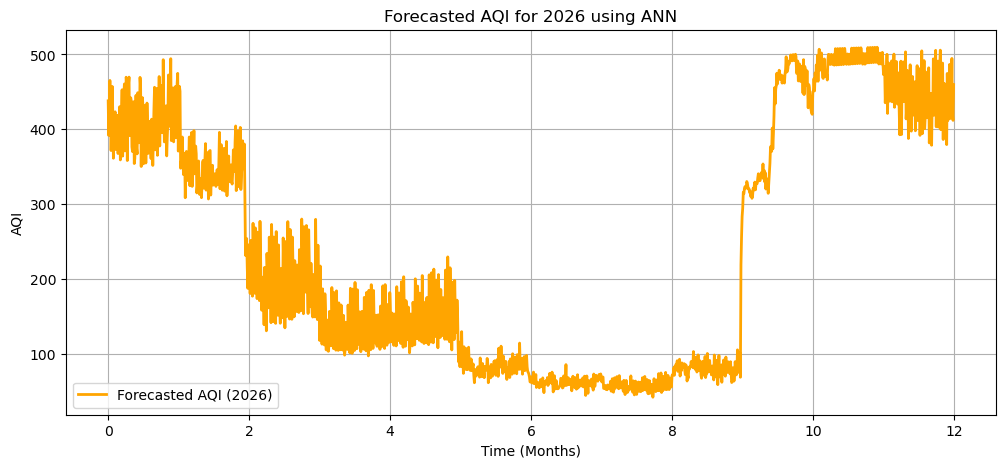

In [94]:
aqi_2026_pred = ann.predict(X_2026_scaled).flatten()
n_samples = len(aqi_2026_pred)
x_months_2026 = np.arange(n_samples) / 121.66
plt.figure(figsize=(12, 5))

plt.plot(
    x_months_2026,
    aqi_2026_pred,
    label='Forecasted AQI (2026)',
    linewidth=2,
    color='orange'
)

plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Forecasted AQI for 2026 using ANN')
plt.legend()
plt.grid(True)

plt.savefig("ann_aqi_forecast_2026.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [95]:
dfJ=pd.read_csv("C:/Users/dhruv/samsung/aqi/NSITJAN.csv")

In [82]:
dfJ

,date,min,max,median,q1,q3,stdev,count
0,2026-01-01T00:00:00.000Z,121.6,201.7,126.25,123.10,133.69,18.920,90
1,2026-01-02T00:00:00.000Z,32.8,385.9,105.65,53.85,191.35,93.263,92
2,2026-01-03T00:00:00.000Z,55.3,93.9,57.40,55.90,62.00,8.232,89
3,2026-01-04T00:00:00.000Z,57.1,2733.6,67.90,59.00,863.30,715.756,93
4,2026-01-05T00:00:00.000Z,4.1,1683.3,50.90,44.00,58.25,396.299,93
5,2026-01-06T00:00:00.000Z,13.5,2570.6,103.50,81.75,188.50,724.131,89
6,2026-01-07T00:00:00.000Z,38.5,813.8,104.80,84.70,122.40,96.980,91
7,2026-01-08T00:00:00.000Z,53.8,750.8,150.70,97.30,278.14,183.107,92
8,2026-01-09T00:00:00.000Z,42.7,381.0,91.60,65.80,119.70,82.398,87
9,2026-01-10T00:00:00.000Z,55.4,146.5,81.90,64.55,96.80,23.900,81


In [83]:
def pm25_to_aqi(pm25):
    """
    Convert PM2.5 (µg/m³) to AQI using CPCB breakpoints
    """
    if pm25 <= 30:
        return round((50/30) * pm25)
    elif pm25 <= 60:
        return round(((100-51)/(60-31)) * (pm25-31) + 51)
    elif pm25 <= 90:
        return round(((200-101)/(90-61)) * (pm25-61) + 101)
    elif pm25 <= 120:
        return round(((300-201)/(120-91)) * (pm25-91) + 201)
    elif pm25 <= 250:
        return round(((400-301)/(250-121)) * (pm25-121) + 301)
    else:
        return round(((500-401)/(500-251)) * (pm25-251) + 401)


In [84]:
dfJ["aqi"] = dfJ["median"].apply(pm25_to_aqi)
dfJ

,date,min,max,median,q1,q3,stdev,count,aqi
0,2026-01-01T00:00:00.000Z,121.6,201.7,126.25,123.10,133.69,18.920,90,305
1,2026-01-02T00:00:00.000Z,32.8,385.9,105.65,53.85,191.35,93.263,92,251
2,2026-01-03T00:00:00.000Z,55.3,93.9,57.40,55.90,62.00,8.232,89,96
3,2026-01-04T00:00:00.000Z,57.1,2733.6,67.90,59.00,863.30,715.756,93,125
4,2026-01-05T00:00:00.000Z,4.1,1683.3,50.90,44.00,58.25,396.299,93,85
5,2026-01-06T00:00:00.000Z,13.5,2570.6,103.50,81.75,188.50,724.131,89,244
6,2026-01-07T00:00:00.000Z,38.5,813.8,104.80,84.70,122.40,96.980,91,248
7,2026-01-08T00:00:00.000Z,53.8,750.8,150.70,97.30,278.14,183.107,92,324
8,2026-01-09T00:00:00.000Z,42.7,381.0,91.60,65.80,119.70,82.398,87,203
9,2026-01-10T00:00:00.000Z,55.4,146.5,81.90,64.55,96.80,23.900,81,172


In [85]:
dfy=dfJ["aqi"]

In [86]:
dfy

0     305
1     251
2      96
3     125
4      85
5     244
6     248
7     324
8     203
9     172
10     86
11    218
12    277
13    221
14    281
15    157
16     86
17    565
18    320
19    204
20     81
21    278
22     81
23     39
24     39
25     85
26    132
27     96
28     85
29    300
30    317
Name: aqi, dtype: int64

In [87]:
dfy.to_csv("nsit_dwarka_jan_2026_aqi.csv", index=False)


In [88]:
# assuming future_2026 dataframe still exists
jan_mask = (future_2026['month'] == 1)
aqi_jan_2026_pred = aqi_2026_pred[jan_mask.values]


In [89]:
n_samples = len(aqi_jan_2026_pred)
x_days = np.arange(n_samples) / 4.0   # 4 readings per day


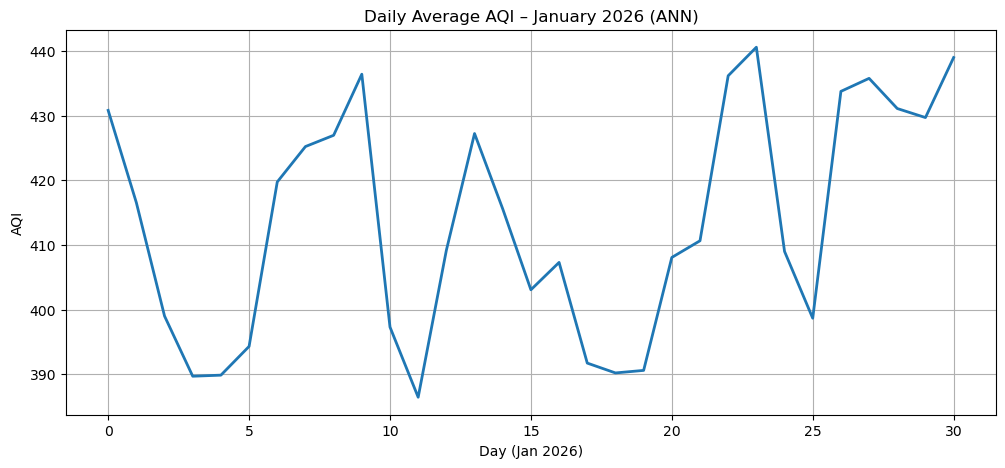

In [90]:
aqi_jan_daily = aqi_jan_2026_pred.reshape(-1, 4).mean(axis=1)

plt.figure(figsize=(12, 5))
plt.plot(aqi_jan_daily, linewidth=2)
plt.xlabel('Day (Jan 2026)')
plt.ylabel('AQI')
plt.title('Daily Average AQI – January 2026 (ANN)')
plt.grid(True)
plt.savefig("ann_aqi_jan_2026_daily.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [91]:
len(dfy), len(aqi_jan_daily)


(31, 31)

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_jan = mean_absolute_error(dfy.values, aqi_jan_daily)
rmse_jan = np.sqrt(mean_squared_error(dfy.values, aqi_jan_daily))

print("ANN January 2026 MAE:", mae_jan)
print("ANN January 2026 RMSE:", rmse_jan)


ANN January 2026 MAE: 231.13658142089844
ANN January 2026 RMSE: 249.04229842789758


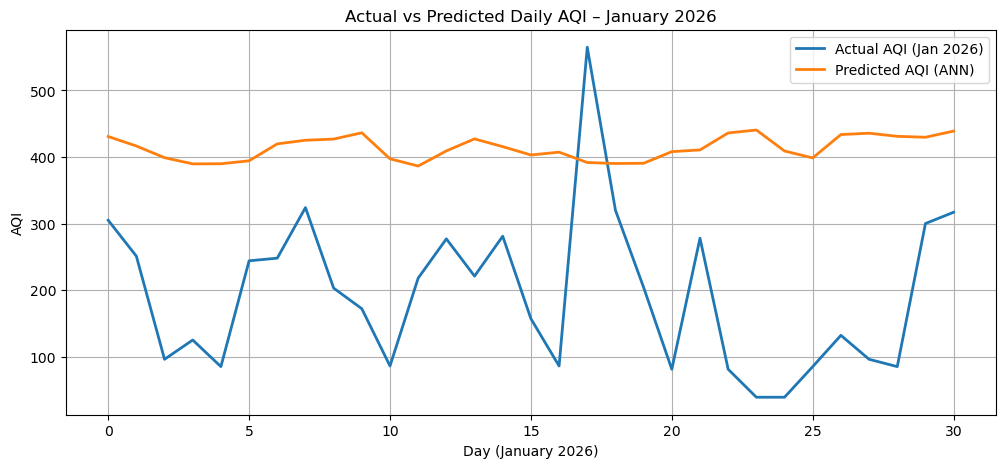

In [93]:
plt.figure(figsize=(12,5))

plt.plot(dfy.values, label="Actual AQI (Jan 2026)", linewidth=2)
plt.plot(aqi_jan_daily, label="Predicted AQI (ANN)", linewidth=2)

plt.xlabel("Day (January 2026)")
plt.ylabel("AQI")
plt.title("Actual vs Predicted Daily AQI – January 2026")
plt.legend()
plt.grid(True)

plt.savefig("ann_jan_2026_actual_vs_predicted.jpg", dpi=300, bbox_inches="tight")
plt.show()
